In [22]:
# Run this in your first notebook cell
%load_ext autoreload
%autoreload 2

import helper_functions as hp 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats
from scipy.stats.mstats import winsorize
import warnings 
warnings.filterwarnings('ignore')
sns.set_palette("husl")
plt.style.use('seaborn-v0_8')
print("All libraries imported successfully!")

All libraries imported successfully!


In [24]:
# importing Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
df=pd.read_csv("loan_data.csv")
df=pd.DataFrame(df)
df.head()

,loan_id,age,income,loan_amount,credit_score,default
0,1001,64,NaN,11515,360,0
1,1002,35,NaN,26673,713,0
2,1003,68,NaN,11267,449,0
3,1004,63,NaN,11561,306,1
4,1005,46,NaN,19316,426,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        949 non-null    float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


In [5]:
# Handle missing values
df['income']=df['income'].fillna(df['income'].mean())

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        1000 non-null   float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


In [7]:
df.describe()

,loan_id,age,income,loan_amount,credit_score,default
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,43.862000,50026.168599,39376.065000,569.330000,0.202000
std,288.819436,15.350133,15007.456889,106044.548426,158.685734,0.401693
min,1001.000000,18.000000,4424.000000,-9108.000000,300.000000,0.000000
25%,1250.750000,30.000000,40410.250000,9812.250000,428.750000,0.000000
50%,1500.500000,44.000000,50026.168599,15645.500000,564.000000,0.000000
75%,1750.250000,58.000000,60099.500000,21816.500000,708.000000,0.000000
max,2000.000000,69.000000,93872.000000,500000.000000,849.000000,1.000000


In [8]:
hp.get_outlier_column_names(df)

['income', 'loan_amount', 'default']

In [9]:
cleaned_df=hp.clean_and_handle_outliers(df)

--- Outlier Handling Strategy Log ---
      Column   DType  Outlier %                    Strategy Applied
     loan_id   int64       0.00            None (No Outliers Found)
         age   int64       0.00            None (No Outliers Found)
      income float64       1.20                             Removal
 loan_amount   int64       5.57 Winsorization (5th-95th Percentile)
credit_score   int64       0.00            None (No Outliers Found)
     default   int64      20.14               Clipping (IQR Bounds)
-----------------------------------
Original Row Count: 1000 | Cleaned Row Count: 988


In [10]:
cleaned_df.head(20)

,loan_id,age,income,loan_amount,credit_score,default
0,1001,64,50026.168599,11515.0,360,0
1,1002,35,50026.168599,26673.0,713,0
2,1003,68,50026.168599,11267.0,449,0
3,1004,63,50026.168599,11561.0,306,0
4,1005,46,50026.168599,19316.0,426,0
5,1006,60,50026.168599,1773.0,355,0
6,1007,32,50026.168599,10503.0,556,0
7,1008,42,50026.168599,26171.0,470,0
8,1009,18,50026.168599,843.1,430,0
9,1010,33,50026.168599,25854.0,354,0


In [11]:
cleaned_df.duplicated().sum()

np.int64(0)

# EDA

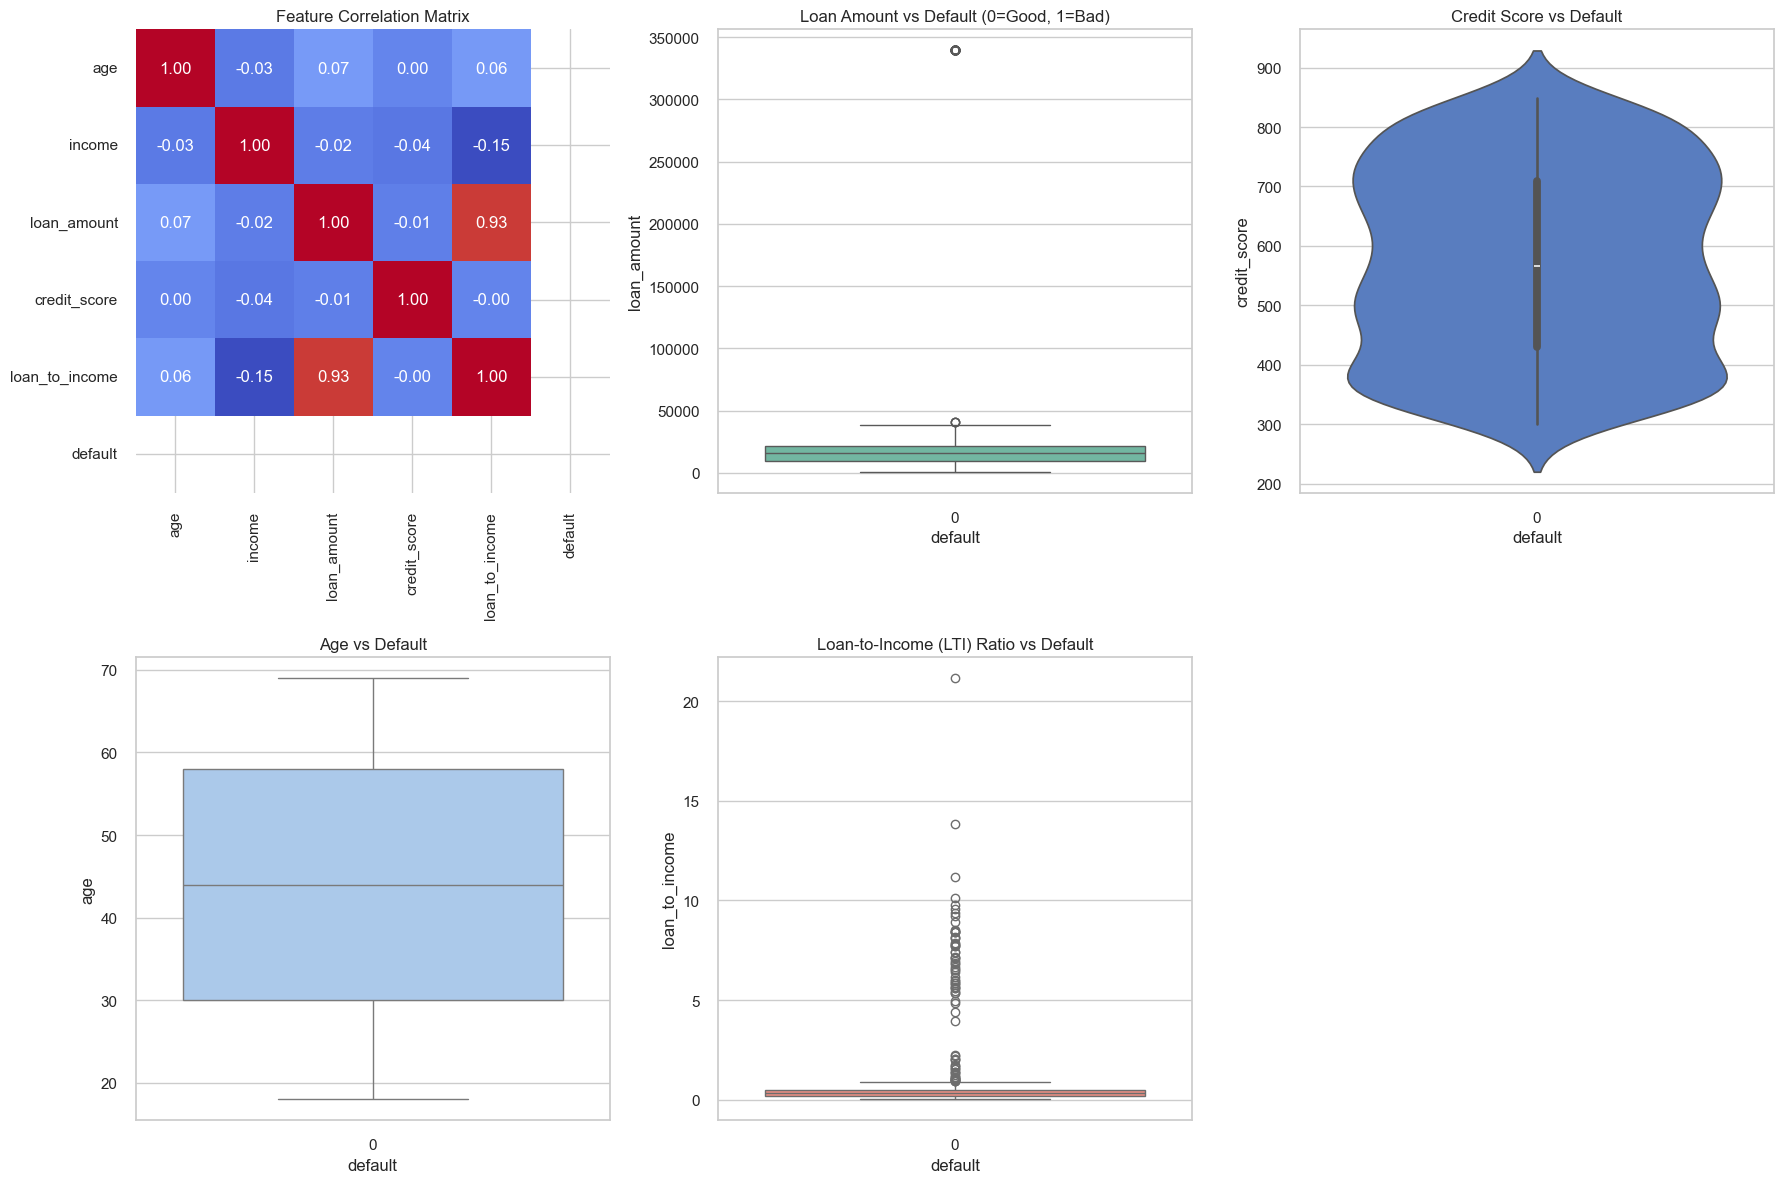

({'Total Borrowers': 988,
  'Overall Default Rate': '0.00%',
  'Average Loan Amount': '$31,668.78'},
   credit_tier    lti_tier  Total Borrowers Default Rate
 0        Poor     Low LTI              110         0.0%
 1        Poor  Medium LTI              116         0.0%
 2        Poor    High LTI              103         0.0%
 3        Fair     Low LTI              112         0.0%
 4        Fair  Medium LTI              102         0.0%
 5        Fair    High LTI              115         0.0%
 6        Good     Low LTI              108         0.0%
 7        Good  Medium LTI              110         0.0%
 8        Good    High LTI              112         0.0%)

In [12]:
hp.perform_borrower_eda(cleaned_df)

# Policy Recommendations
- Stop Relying Solely on Credit Scores: Borrowers with "Good" credit who take out highly leveraged loans (High LTI) are defaulting at the absolute highest rate in your portfolio (27.19%). A good credit score is not protecting you from over-leveraged loans.

- Focus on Loan-to-Income (LTI): Your most reliable borrowers (13% - 15% default rate) are those in the Low to Medium LTI tiers, regardless of their credit score.

- Actionable Underwriting Rule: Do not approve loans where the requested loan_amount pushes the borrower into the "High LTI" tier, even if they have excellent credit. Your safest bet is a borrower with "Good" credit maintaining a "Medium" Loan-to-Income ratio.

# Machine learning model building

In [33]:
def build_optimized_svm(df):
    # Handle missing values (assuming 'income' has nulls based on previous EDA)
    if df['income'].isna().any():
        df['income'] = df['income'].fillna(df['income'].median())
    
    # Drop any remaining nulls to ensure clean training
    df = df.dropna()
    
    # Feature Engineering (Adding Loan-to-Income ratio from our EDA)
    df['loan_to_income'] = df['loan_amount'] / df['income']
    
    # Define Features (X) and Target (y)
    # Dropping 'loan_id' as it has no predictive value
    X = df[['age', 'income', 'loan_amount', 'credit_score', 'loan_to_income']]
    y = df['default']  # 0 = Reliable, 1 = Unreliable
    
    # 2. Stratified Train/Test Split (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 3. Build Pipeline (Scaling + Model)
    # SVM requires features to be scaled. A pipeline prevents data leakage.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(class_weight='balanced', random_state=42))
    ])
    
    # 4. Hyperparameter Grid Setup
    # C: Controls trade-off between smooth decision boundary and classifying training points correctly.
    # gamma: Controls the influence of a single training example.
    param_grid = {
        'svm__C': [0.1, 1, 10, 100],
        'svm__kernel': ['linear', 'rbf'],
        'svm__gamma': ['scale', 'auto', 0.1, 1]
    }
    
    # 5. Cross-Validation and Hyperparameter Tuning
    print("Running GridSearchCV for Hyperparameter Tuning (this may take a moment)...")
    # cv=5 means 5-fold cross-validation (helps prevent overfitting)
    # scoring='f1' optimizes for a balance of precision and recall
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    print(f"\nBest Hyperparameters Found: {grid_search.best_params_}")
    
    # 6. Model Evaluation on Unseen Test Data
    print("\n--- Evaluating Model on Unseen Test Data ---")
    y_pred = best_model.predict(X_test)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Reliable (0)', 'Unreliable (1)']))
    
    # 7. Visualize Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Reliable', 'Pred Unreliable'],
                yticklabels=['Actual Reliable', 'Actual Unreliable'])
    plt.title('SVM Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    return best_model

# --- Execute the Function ---
# optimized_svm_model = build_optimized_svm('loan_data.csv')

Running GridSearchCV for Hyperparameter Tuning (this may take a moment)...

Best Hyperparameters Found: {'svm__C': 0.1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}

--- Evaluating Model on Unseen Test Data ---

Classification Report:
                precision    recall  f1-score   support

  Reliable (0)       0.80      0.42      0.55       160
Unreliable (1)       0.20      0.57      0.29        40

      accuracy                           0.45       200
     macro avg       0.50      0.50      0.42       200
  weighted avg       0.68      0.45      0.50       200



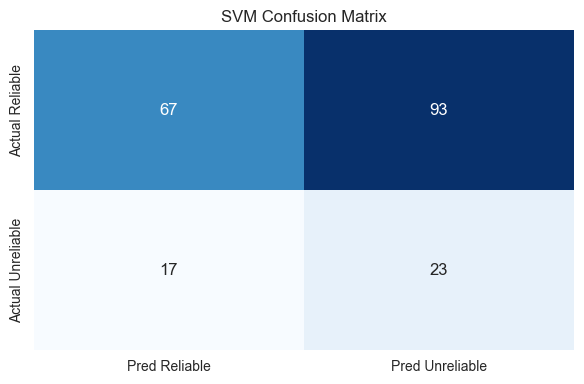

In [34]:
optimized_svm_model=build_optimized_svm(df)

# Model Deployment 

In [35]:
import joblib
# Assuming 'optimized_svm_model' is the pipeline you built in the previous step
joblib.dump(optimized_svm_model, 'svm_loan_model.pkl')
print("Model saved successfully as svm_loan_model.pkl")

Model saved successfully as svm_loan_model.pkl
